# QRT Challenge - Exploratory Data Analysis

**Goal**: Predict the sign of an allocation's next-day return (binary classification)

**Features**:
- `RET_1` to `RET_20`: 20-day history of allocation returns (RET_1 = yesterday)
- `SIGNED_VOLUME_1` to `SIGNED_VOLUME_20`: 20-day history of volume-weighted liquidity
- `MEDIAN_DAILY_TURNOVER`: Allocation's median daily turnover
- `GROUP`: Anonymized allocation group
- `ALLOCATION`: Allocation identifier

**target**: `target` - next day return (we predict the sign: 1 if positive, 0 if negative)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [8]:
# Load sample data (faster for EDA)
X_train = pd.read_csv('Data/X_train_sample.csv')
y_train = pd.read_csv('Data/y_train_sample.csv')

# Merge for easier analysis
df = X_train.merge(y_train, on='ROW_ID')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (50000, 46)
Columns: ['ROW_ID', 'TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP', 'target']


## 1. Basic Data Overview

In [9]:
# Basic info
print("=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)
print("\n")

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

DATA TYPES
ROW_ID                     int64
TS                        object
ALLOCATION                object
RET_20                   float64
RET_19                   float64
RET_18                   float64
RET_17                   float64
RET_16                   float64
RET_15                   float64
RET_14                   float64
RET_13                   float64
RET_12                   float64
RET_11                   float64
RET_10                   float64
RET_9                    float64
RET_8                    float64
RET_7                    float64
RET_6                    float64
RET_5                    float64
RET_4                    float64
RET_3                    float64
RET_2                    float64
RET_1                    float64
SIGNED_VOLUME_20         float64
SIGNED_VOLUME_19         float64
SIGNED_VOLUME_18         float64
SIGNED_VOLUME_17         float64
SIGNED_VOLUME_16         float64
SIGNED_VOLUME_15         float64
SIGNED_VOLUME_14         float64

In [10]:
df.head(10)

,ROW_ID,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,RET_12,RET_11,RET_10,RET_9,RET_8,RET_7,RET_6,RET_5,RET_4,RET_3,RET_2,RET_1,SIGNED_VOLUME_20,SIGNED_VOLUME_19,SIGNED_VOLUME_18,SIGNED_VOLUME_17,SIGNED_VOLUME_16,SIGNED_VOLUME_15,SIGNED_VOLUME_14,SIGNED_VOLUME_13,SIGNED_VOLUME_12,SIGNED_VOLUME_11,SIGNED_VOLUME_10,SIGNED_VOLUME_9,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP,target
0,54916,DATE_0273,ALLOCATION_04,0.001418,-0.005199,-0.001927,-0.005260,0.001290,-0.007002,-0.005132,-0.005958,0.004751,0.001515,0.000833,-0.002046,-0.002540,-0.000927,-0.001242,0.004070,-0.001315,-0.000744,-0.017057,-0.008758,-1.000000,0.141724,-1.000000,-1.281457,-0.634374,-0.494262,-1.542679,-1.826218,-2.126363,-1.372069,-0.696526,-0.785250,-0.420694,-0.830174,-2.799455,-2.515563,-1.308122,-1.267219,-5.731012,NaN,0.001514,2,0.000459
1,173590,DATE_0833,ALLOCATION_232,0.001403,0.001136,0.000942,-0.000066,0.001249,-0.001917,-0.000179,-0.000331,0.002809,0.000360,0.001434,-0.000362,-0.001578,0.002800,-0.000362,0.002246,0.002953,-0.001025,-0.000138,0.000171,1.000000,2.255133,0.759596,1.279160,1.005330,1.262885,0.669280,0.941372,1.389594,0.942097,0.872219,0.681294,0.980947,0.941799,1.238613,1.434697,0.994068,1.088088,1.175044,NaN,0.019619,2,-0.002582
2,467223,DATE_2233,ALLOCATION_194,-0.001004,-0.001696,0.007416,-0.004928,0.002904,0.001848,0.000629,0.001871,-0.004272,0.002095,0.000133,0.004378,0.001812,0.000512,0.001008,-0.001305,0.001271,0.000963,-0.005637,0.001821,1.000000,0.741095,0.728739,0.735563,1.000000,1.081209,0.773058,0.939892,1.245959,1.197592,1.405387,0.897420,1.557477,1.844326,1.586183,1.201943,0.654231,0.713175,0.671394,NaN,0.014572,3,0.000814
3,87696,DATE_0427,ALLOCATION_155,-0.000611,-0.000932,0.001631,0.001376,0.001931,0.000390,0.001518,-0.001554,0.001454,-0.003450,0.000275,-0.001081,0.001517,0.000648,0.000690,-0.000161,0.000054,-0.001647,-0.000955,0.002734,1.671321,0.991638,0.703952,2.849411,1.690809,2.134893,2.867203,1.593289,1.000000,0.979303,1.789410,1.908827,0.818489,1.687620,1.578121,1.867823,1.215464,0.988337,0.616048,0.850059,0.002342,2,-0.000674
4,502178,DATE_2406,ALLOCATION_227,0.001423,-0.002167,-0.002938,-0.001488,0.001576,0.000958,-0.000114,0.001670,-0.001266,0.000121,-0.000522,0.001649,-0.000571,-0.002335,0.000527,0.000552,-0.002926,0.002371,-0.000587,0.002528,1.000000,0.289536,1.427408,1.120503,0.667777,-1.307808,1.992477,-1.505565,2.198236,0.724523,1.068927,1.807148,7.315839,3.571877,1.408009,3.163936,2.914847,1.643143,1.756064,1.049763,0.027156,2,-0.002676
5,73708,DATE_0363,ALLOCATION_173,0.003743,0.006223,0.001977,-0.000011,-0.002390,0.002007,-0.000272,0.002502,0.001675,-0.001989,-0.000703,-0.001969,0.000481,0.001895,-0.003691,-0.007013,-0.009205,-0.003521,0.005332,0.003615,-0.579923,-0.326246,0.248921,-0.433371,-3.662462,-0.179445,-2.753394,-1.000000,0.041625,-4.602869,-5.056305,-2.729630,-1.770915,0.759953,1.058206,3.464786,0.381576,2.063962,1.998478,NaN,0.218002,1,0.004186
6,417420,DATE_1995,ALLOCATION_110,-0.000417,-0.000573,0.001269,0.005308,0.002181,-0.003421,0.005045,0.000573,-0.001020,0.000715,-0.002672,-0.003346,-0.005026,0.000146,0.006663,0.002591,-0.001494,0.002463,-0.004107,-0.003714,0.301964,1.000000,1.016499,1.000000,0.914379,0.427604,0.888805,0.499085,0.549404,0.658451,0.879163,-0.379308,0.238729,-0.973365,1.626135,0.613827,1.014356,-0.078129,0.624259,NaN,0.024098,3,-0.004841
7,407795,DATE_1950,ALLOCATION_227,0.002165,-0.002548,-0.002014,-0.000154,0.003810,0.001923,-0.005508,-0.002263,-0.000270,-0.000200,-0.000044,-0.000488,0.001259,0.001891,-0.000084,0.004975,-0.002520,-0.000634,-0.000961,-0.000406,1.007179,0.703692,0.650626,0.679929,0.454000,0.720208,0.495466,0.866482,0.824735,1.000000,0.865461,1.186862,1.018702,1.353033,1.194789,0.657371,0.940347,0.576734,0.446222,NaN,0.015655,2,0.000575
8,161595,DATE_0777,ALLOCATION_157,0.001988,0.002365,-0.000011,-0.001589,-0.000574,0.

In [11]:
# Summary statistics for return columns
ret_cols = [f'RET_{i}' for i in range(1, 21)]
df[ret_cols + ['target']].describe()

,RET_1,RET_2,RET_3,RET_4,RET_5,RET_6,RET_7,RET_8,RET_9,RET_10,RET_11,RET_12,RET_13,RET_14,RET_15,RET_16,RET_17,RET_18,RET_19,RET_20,target
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49999.000000,49999.000000,49998.000000,49995.000000,49995.000000,49995.000000,50000.000000
mean,0.000094,0.000021,0.000049,0.000028,0.000034,0.000027,0.000019,0.000004,0.000018,0.000026,0.000024,0.000022,0.000026,0.000016,0.000001,0.000027,0.000010,0.000011,0.000024,0.000027,0.000027
std,0.003068,0.003038,0.003033,0.003062,0.003017,0.003056,0.003030,0.003061,0.003063,0.003029,0.003055,0.003083,0.003038,0.003103,0.003045,0.003052,0.003097,0.003139,0.003047,0.003066,0.003121
min,-0.039351,-0.034816,-0.043676,-0.041074,-0.038481,-0.043569,-0.039359,-0.033447,-0.039803,-0.043727,-0.040331,-0.045706,-0.040403,-0.040715,-0.040677,-0.046149,-0.033924,-0.039322,-0.046987,-0.033620,-0.044744
25%,-0.001451,-0.001514,-0.001492,-0.001491,-0.001508,-0.001524,-0.001533,-0.001536,-0.001529,-0.001527,-0.001535,-0.001536,-0.001525,-0.001534,-0.001541,-0.001525,-0.001549,-0.001558,-0.001528,-0.001538,-0.001525
50%,0.000075,0.000027,0.000032,0.000047,0.000036,0.000026,0.000023,0.000021,0.000027,0.000029,0.000025,0.000022,0.000023,0.000036,0.000014,0.000050,0.000024,0.000024,0.000040,0.000046,0.000045
75%,0.001613,0.001580,0.001610,0.001611,0.001610,0.001592,0.001593,0.001577,0.001605,0.001593,0.001609,0.001601,0.001607,0.001590,0.001584,0.001608,0.001608,0.001598,0.001617,0.001615,0.001596
max,0.111031,0.053955,0.034165,0.031132,0.043849,0.043903,0.046343,0.032882,0.042322,0.032603,0.031740,0.108728,0.051161,0.108710,0.048134,0.044668,0.037159,0.130503,0.031675,0.041428,0.033833


## 2. Target Distribution

/var/folders/bk/qpt56ww928z8p47c40hrn6j00000gn/T/ipykernel_37090/1545916292.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df[df['target'] < 0]['target'], df[df['target'] > 0]['target']],


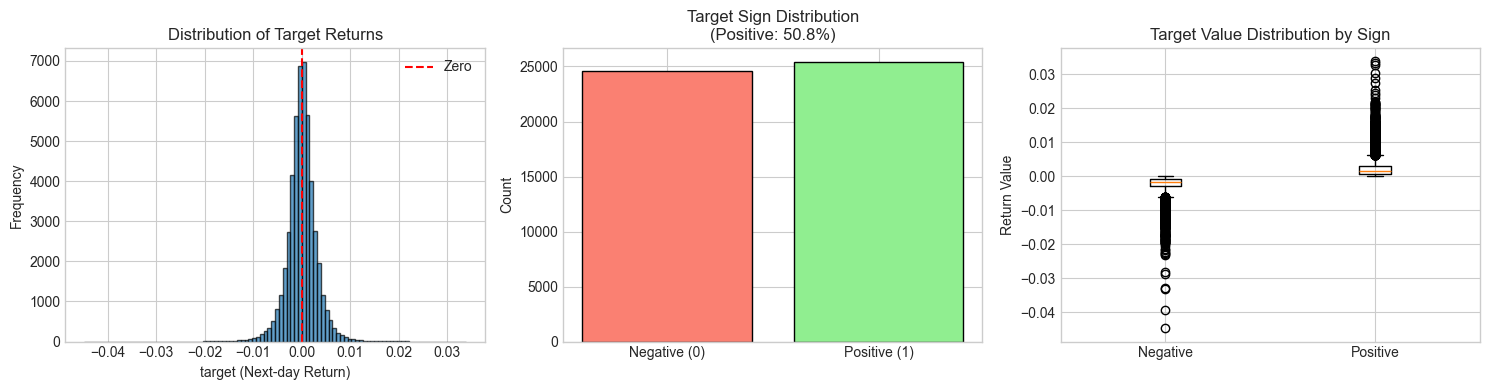

Class balance: 50.84% positive


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target distribution (continuous)
axes[0].hist(df['target'], bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', label='Zero')
axes[0].set_xlabel('target (Next-day Return)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Target Returns')
axes[0].legend()

# Binary target (what we predict)
df['target_SIGN'] = (df['target'] > 0).astype(int)
target_counts = df['target_SIGN'].value_counts()
axes[1].bar(['Negative (0)', 'Positive (1)'], [target_counts[0], target_counts[1]], 
            color=['salmon', 'lightgreen'], edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Target Sign Distribution\n(Positive: {target_counts[1]/len(df)*100:.1f}%)')

# Box plot of target by sign
axes[2].boxplot([df[df['target'] < 0]['target'], df[df['target'] > 0]['target']], 
                labels=['Negative', 'Positive'])
axes[2].set_ylabel('Return Value')
axes[2].set_title('Target Value Distribution by Sign')

plt.tight_layout()
plt.show()

print(f"Class balance: {target_counts[1]/len(df)*100:.2f}% positive")

## 3. Return Features Analysis

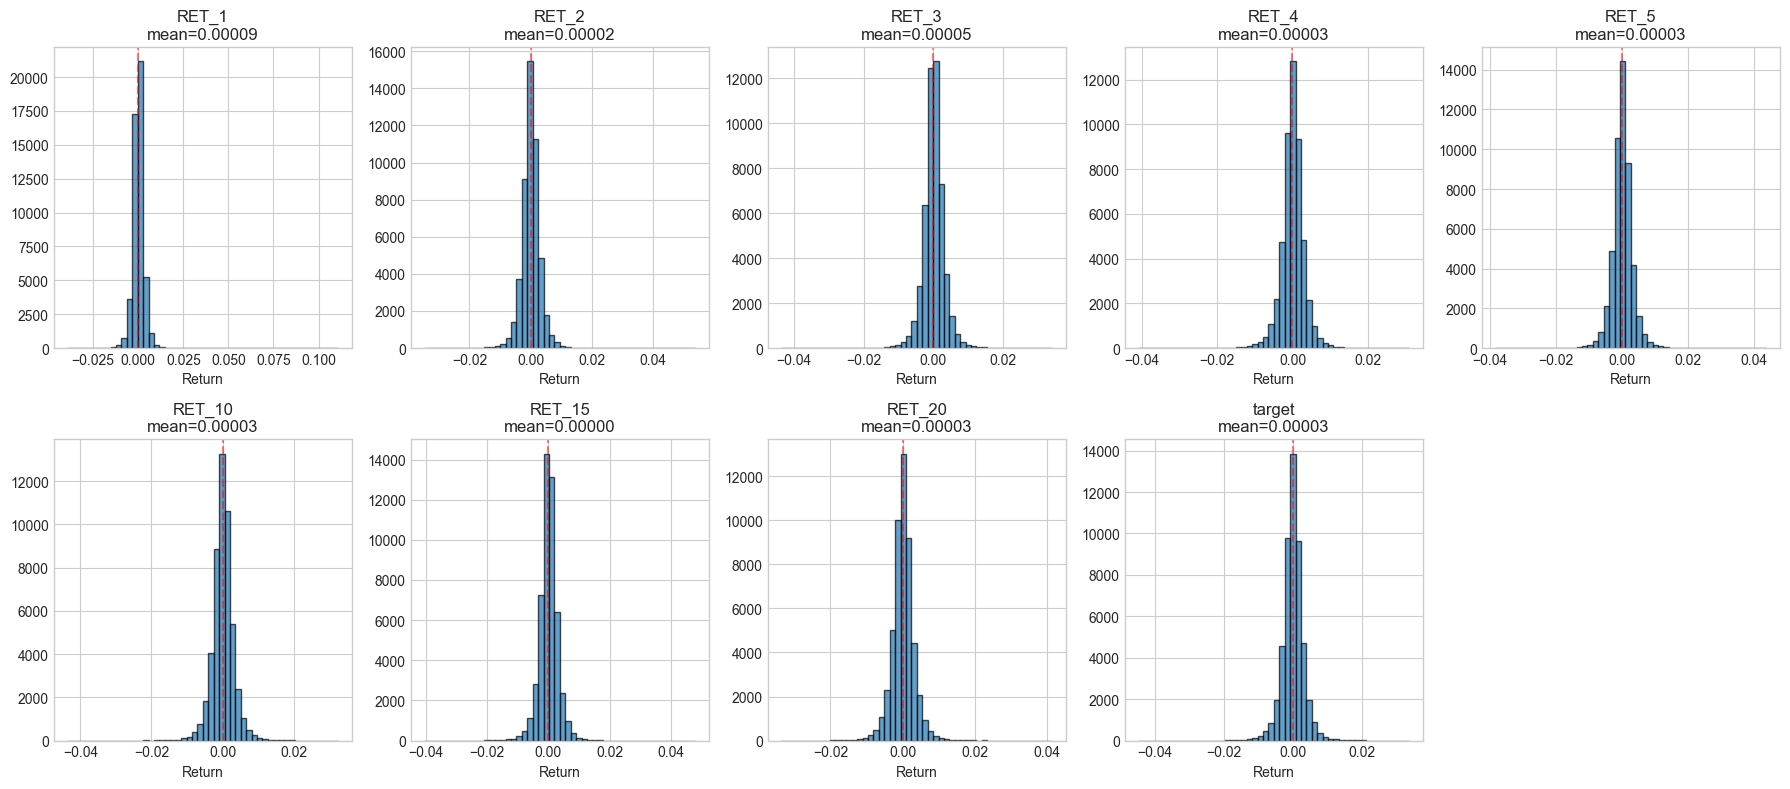

In [13]:
# Distribution of returns across different lags
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate([f'RET_{j}' for j in [1, 2, 3, 4, 5, 10, 15, 20]] + ['target']):
    if i < len(axes):
        axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
        axes[i].set_title(f'{col}\nmean={df[col].mean():.5f}')
        axes[i].set_xlabel('Return')

# Hide the last empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

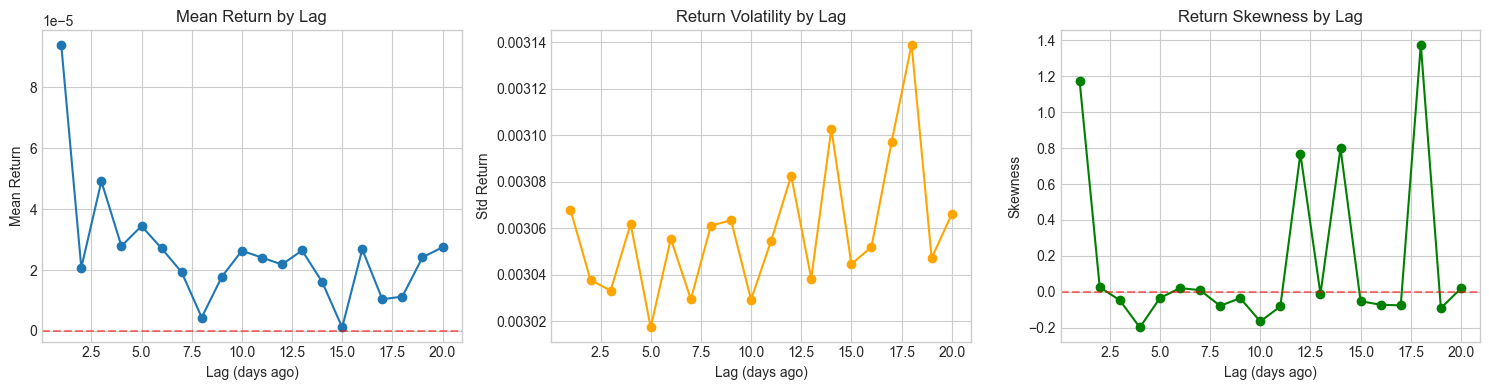

In [14]:
# How do return statistics change across lags?
ret_stats = pd.DataFrame({
    'lag': range(1, 21),
    'mean': [df[f'RET_{i}'].mean() for i in range(1, 21)],
    'std': [df[f'RET_{i}'].std() for i in range(1, 21)],
    'skew': [df[f'RET_{i}'].skew() for i in range(1, 21)],
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ret_stats['lag'], ret_stats['mean'], marker='o')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Lag (days ago)')
axes[0].set_ylabel('Mean Return')
axes[0].set_title('Mean Return by Lag')

axes[1].plot(ret_stats['lag'], ret_stats['std'], marker='o', color='orange')
axes[1].set_xlabel('Lag (days ago)')
axes[1].set_ylabel('Std Return')
axes[1].set_title('Return Volatility by Lag')

axes[2].plot(ret_stats['lag'], ret_stats['skew'], marker='o', color='green')
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Lag (days ago)')
axes[2].set_ylabel('Skewness')
axes[2].set_title('Return Skewness by Lag')

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

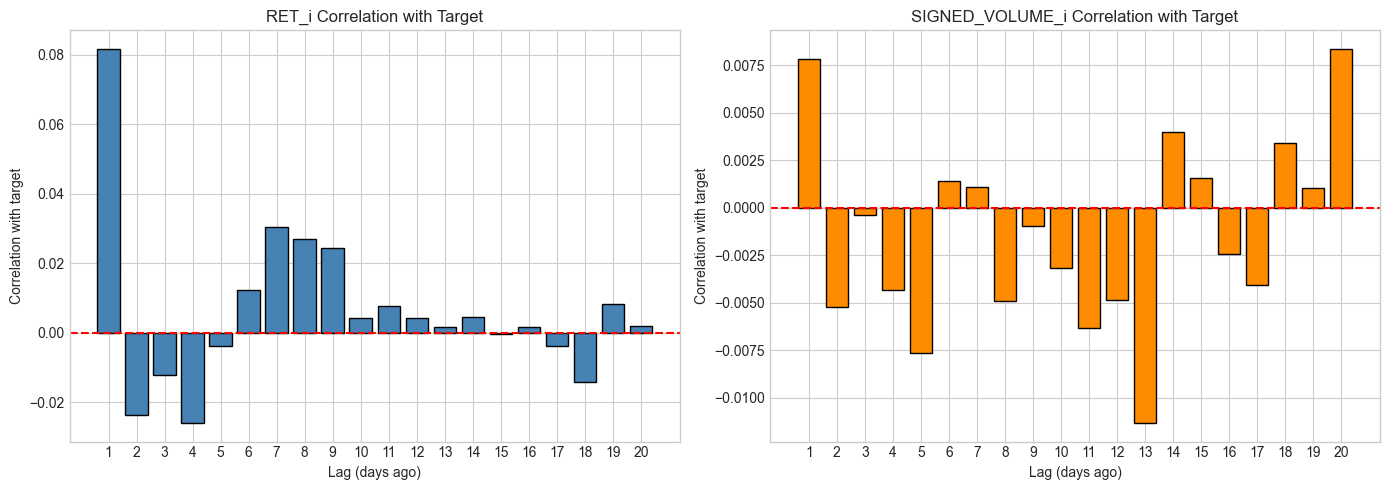

Top 5 RET correlations with target:
RET_1    0.081604
RET_7    0.030361
RET_8    0.027117
RET_4    0.025919
RET_9    0.024422
Name: target, dtype: float64


In [15]:
# Correlation of each feature with target
ret_cols = [f'RET_{i}' for i in range(1, 21)]
vol_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

ret_corr = df[ret_cols + ['target']].corr()['target'].drop('target')
vol_corr = df[vol_cols + ['target']].corr()['target'].drop('target')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return correlations
axes[0].bar(range(1, 21), ret_corr.values, color='steelblue', edgecolor='black')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Lag (days ago)')
axes[0].set_ylabel('Correlation with target')
axes[0].set_title('RET_i Correlation with Target')
axes[0].set_xticks(range(1, 21))

# Volume correlations
axes[1].bar(range(1, 21), vol_corr.values, color='darkorange', edgecolor='black')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Lag (days ago)')
axes[1].set_ylabel('Correlation with target')
axes[1].set_title('SIGNED_VOLUME_i Correlation with Target')
axes[1].set_xticks(range(1, 21))

plt.tight_layout()
plt.show()

print("Top 5 RET correlations with target:")
print(ret_corr.abs().sort_values(ascending=False).head())

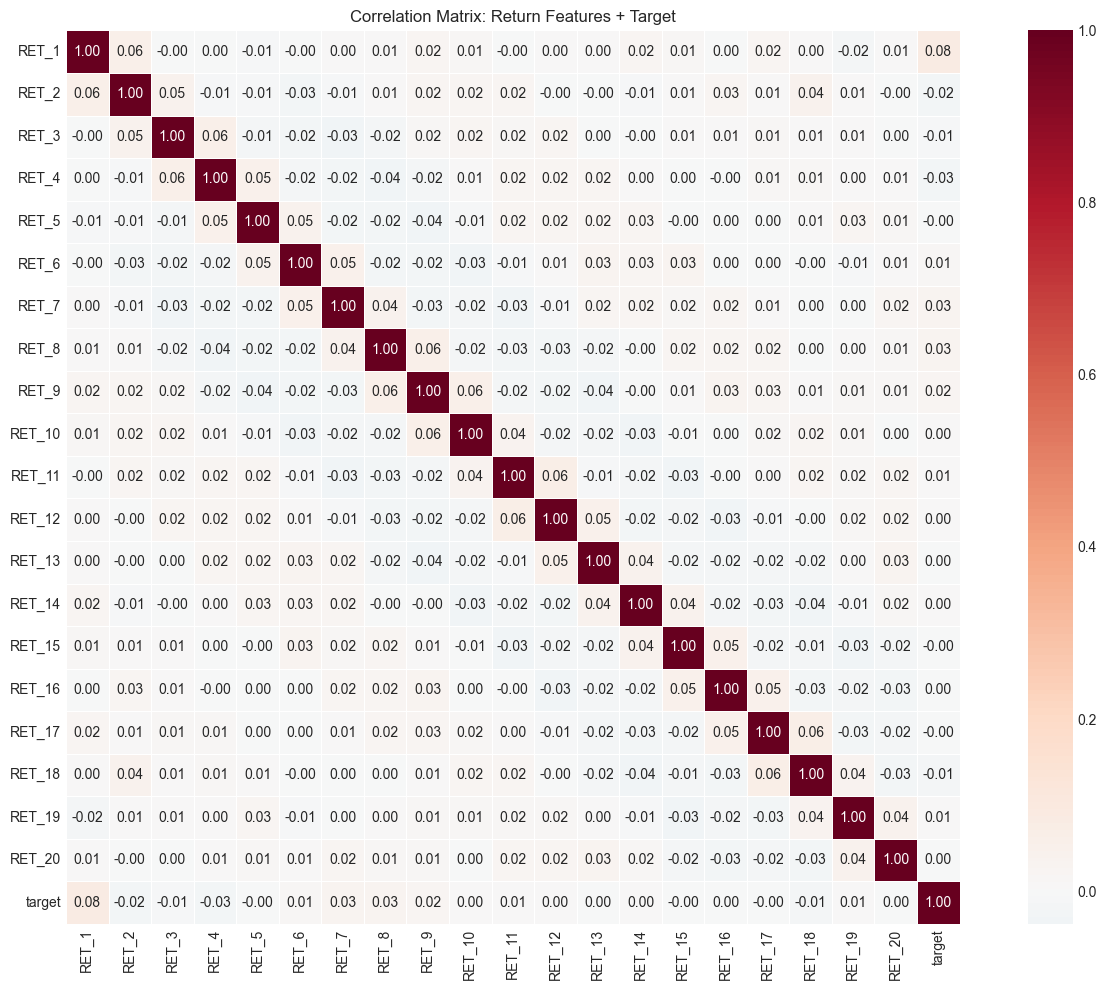

In [16]:
# Correlation heatmap for return features
plt.figure(figsize=(14, 10))
corr_matrix = df[ret_cols + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Return Features + Target')
plt.tight_layout()
plt.show()

## 5. Group Analysis

Number of unique GROUPs: 4
Number of unique ALLOCATIONs: 278
Number of unique timestamps: 2521


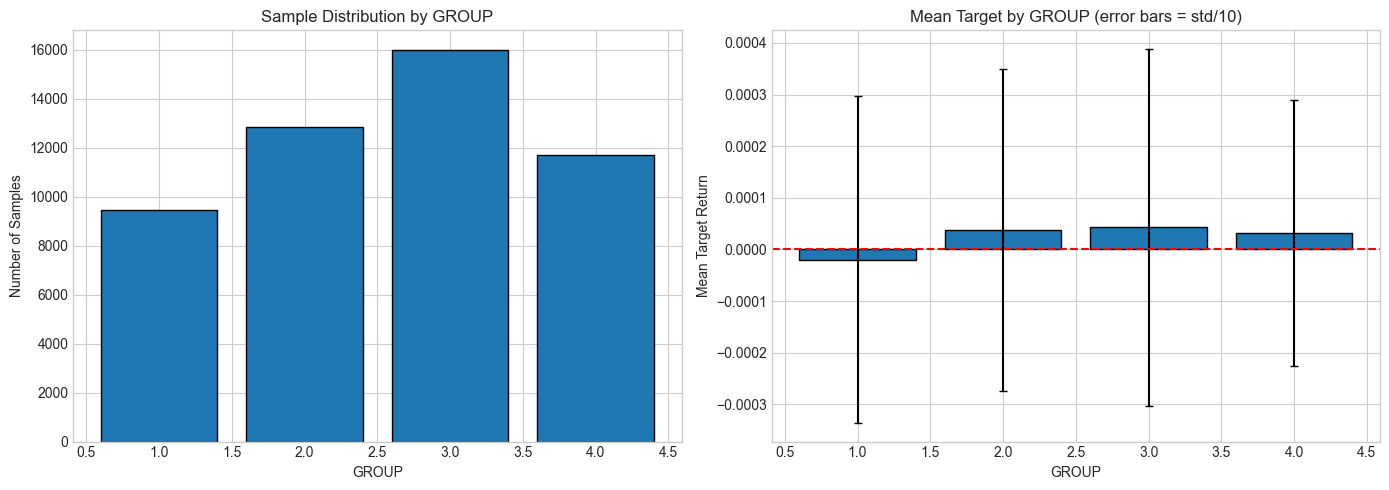

In [17]:
# How many groups? How are samples distributed?
print(f"Number of unique GROUPs: {df['GROUP'].nunique()}")
print(f"Number of unique ALLOCATIONs: {df['ALLOCATION'].nunique()}")
print(f"Number of unique timestamps: {df['TS'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Samples per group
group_counts = df['GROUP'].value_counts().sort_index()
axes[0].bar(group_counts.index, group_counts.values, edgecolor='black')
axes[0].set_xlabel('GROUP')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Sample Distribution by GROUP')

# Target mean by group
group_target = df.groupby('GROUP')['target'].agg(['mean', 'std'])
axes[1].bar(group_target.index, group_target['mean'], yerr=group_target['std']/10, 
            edgecolor='black', capsize=3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('GROUP')
axes[1].set_ylabel('Mean Target Return')
axes[1].set_title('Mean Target by GROUP (error bars = std/10)')

plt.tight_layout()
plt.show()

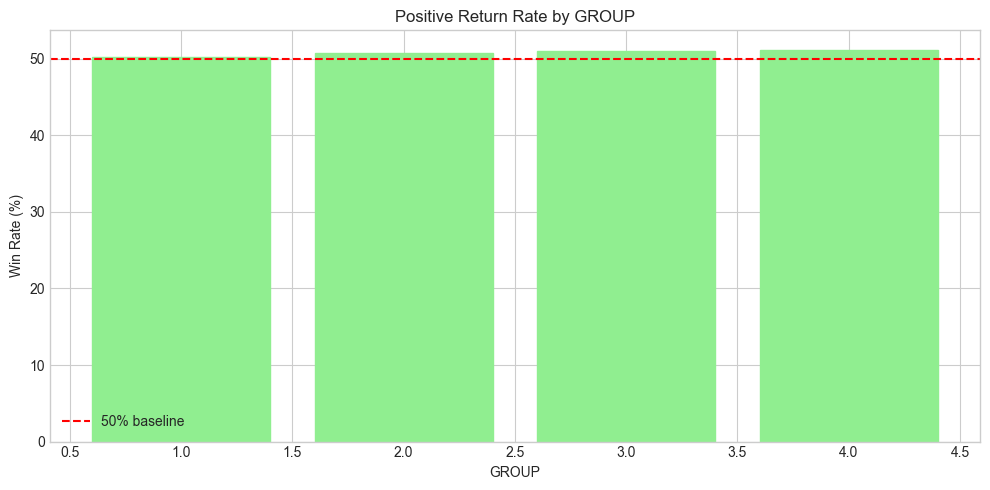

Win rate by GROUP:
GROUP
1    50.21
2    50.83
3    50.98
4    51.16
Name: target_SIGN, dtype: float64


In [18]:
# Win rate (positive return %) by group
group_win_rate = df.groupby('GROUP')['target_SIGN'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(group_win_rate.index, group_win_rate.values, edgecolor='black')
plt.axhline(50, color='red', linestyle='--', label='50% baseline')
plt.xlabel('GROUP')
plt.ylabel('Win Rate (%)')
plt.title('Positive Return Rate by GROUP')
plt.legend()

# Color bars based on win rate
for bar, rate in zip(bars, group_win_rate.values):
    bar.set_color('lightgreen' if rate > 50 else 'salmon')

plt.tight_layout()
plt.show()

print("Win rate by GROUP:")
print(group_win_rate.round(2))

## 6. Turnover Analysis

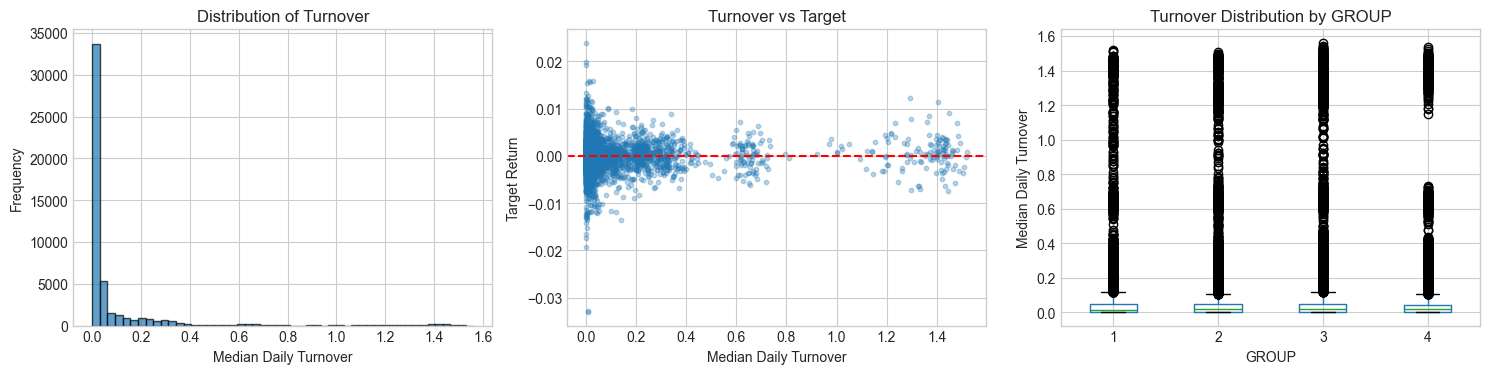

Correlation between TURNOVER and target: 0.0133


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Turnover distribution
axes[0].hist(df['MEDIAN_DAILY_TURNOVER'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Median Daily Turnover')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Turnover')

# Turnover vs Target (scatter)
sample_idx = np.random.choice(len(df), min(5000, len(df)), replace=False)
axes[1].scatter(df.iloc[sample_idx]['MEDIAN_DAILY_TURNOVER'], 
                df.iloc[sample_idx]['target'], alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Median Daily Turnover')
axes[1].set_ylabel('Target Return')
axes[1].set_title('Turnover vs Target')

# Turnover by group
df.boxplot(column='MEDIAN_DAILY_TURNOVER', by='GROUP', ax=axes[2])
axes[2].set_xlabel('GROUP')
axes[2].set_ylabel('Median Daily Turnover')
axes[2].set_title('Turnover Distribution by GROUP')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# Correlation
print(f"Correlation between TURNOVER and target: {df['MEDIAN_DAILY_TURNOVER'].corr(df['target']):.4f}")

## 7. RET_1 Deep Dive (Most Important Feature)

/var/folders/bk/qpt56ww928z8p47c40hrn6j00000gn/T/ipykernel_37090/4258345935.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_win_rate = df.groupby('RET_1_quintile')['target_SIGN'].mean() * 100
/var/folders/bk/qpt56ww928z8p47c40hrn6j00000gn/T/ipykernel_37090/4258345935.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_mean = df.groupby('RET_1_quintile')['target'].mean() * 100  # in bps


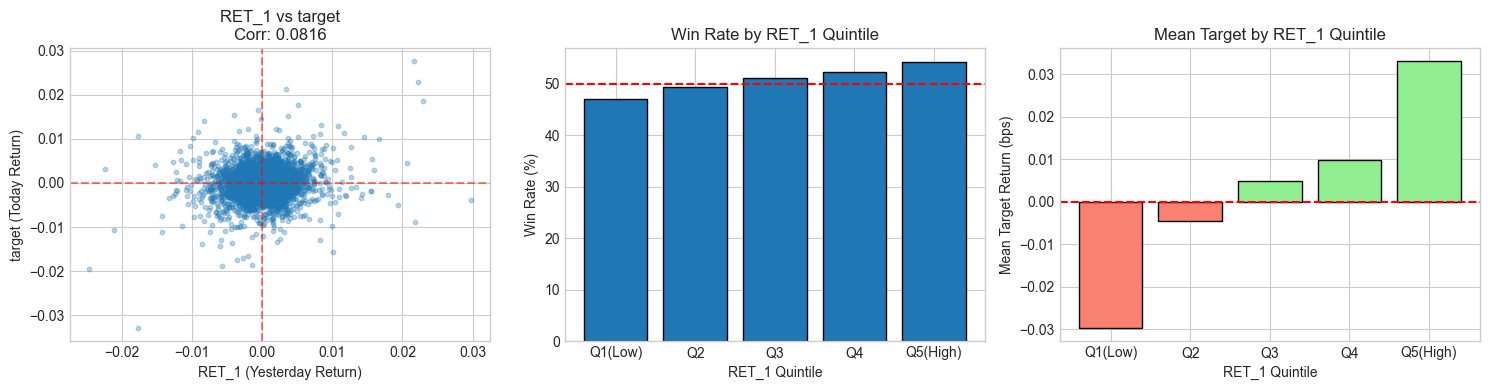

In [20]:
# RET_1 appears to be the most predictive feature - let's analyze it
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RET_1 vs target scatter
sample_idx = np.random.choice(len(df), min(5000, len(df)), replace=False)
axes[0].scatter(df.iloc[sample_idx]['RET_1'], df.iloc[sample_idx]['target'], 
                alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('RET_1 (Yesterday Return)')
axes[0].set_ylabel('target (Today Return)')
axes[0].set_title(f'RET_1 vs target\nCorr: {df["RET_1"].corr(df["target"]):.4f}')

# Win rate by RET_1 quintile
df['RET_1_quintile'] = pd.qcut(df['RET_1'], 5, labels=['Q1(Low)', 'Q2', 'Q3', 'Q4', 'Q5(High)'])
quintile_win_rate = df.groupby('RET_1_quintile')['target_SIGN'].mean() * 100
axes[1].bar(quintile_win_rate.index, quintile_win_rate.values, edgecolor='black')
axes[1].axhline(50, color='red', linestyle='--')
axes[1].set_xlabel('RET_1 Quintile')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Win Rate by RET_1 Quintile')

# Mean target by RET_1 quintile
quintile_mean = df.groupby('RET_1_quintile')['target'].mean() * 100  # in bps
colors = ['salmon' if x < 0 else 'lightgreen' for x in quintile_mean.values]
axes[2].bar(quintile_mean.index, quintile_mean.values, color=colors, edgecolor='black')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('RET_1 Quintile')
axes[2].set_ylabel('Mean Target Return (bps)')
axes[2].set_title('Mean Target by RET_1 Quintile')

plt.tight_layout()
plt.show()

# Clean up
df.drop('RET_1_quintile', axis=1, inplace=True)

In [21]:
# Is there momentum or mean reversion?
# Momentum: RET_1 positive -> target positive (same sign)
# Mean reversion: RET_1 positive -> target negative (opposite sign)

df['RET_1_SIGN'] = (df['RET_1'] > 0).astype(int)

cross_tab = pd.crosstab(df['RET_1_SIGN'], df['target_SIGN'], normalize='index') * 100
cross_tab.index = ['RET_1 < 0', 'RET_1 > 0']
cross_tab.columns = ['target < 0', 'target > 0']

print("Conditional probabilities (%):\n")
print(cross_tab.round(2))
print("\n")

# Interpretation
momentum_evidence = cross_tab.loc['RET_1 > 0', 'target > 0'] > cross_tab.loc['RET_1 < 0', 'target > 0']
print(f"Evidence of MOMENTUM: {momentum_evidence}")
print(f"If RET_1 > 0: {cross_tab.loc['RET_1 > 0', 'target > 0']:.1f}% chance target > 0")
print(f"If RET_1 < 0: {cross_tab.loc['RET_1 < 0', 'target > 0']:.1f}% chance target > 0")

Conditional probabilities (%):

           target < 0  target > 0
RET_1 < 0       51.22       48.78
RET_1 > 0       47.23       52.77


Evidence of MOMENTUM: True
If RET_1 > 0: 52.8% chance target > 0
If RET_1 < 0: 48.8% chance target > 0


## 8. Volume Features Analysis

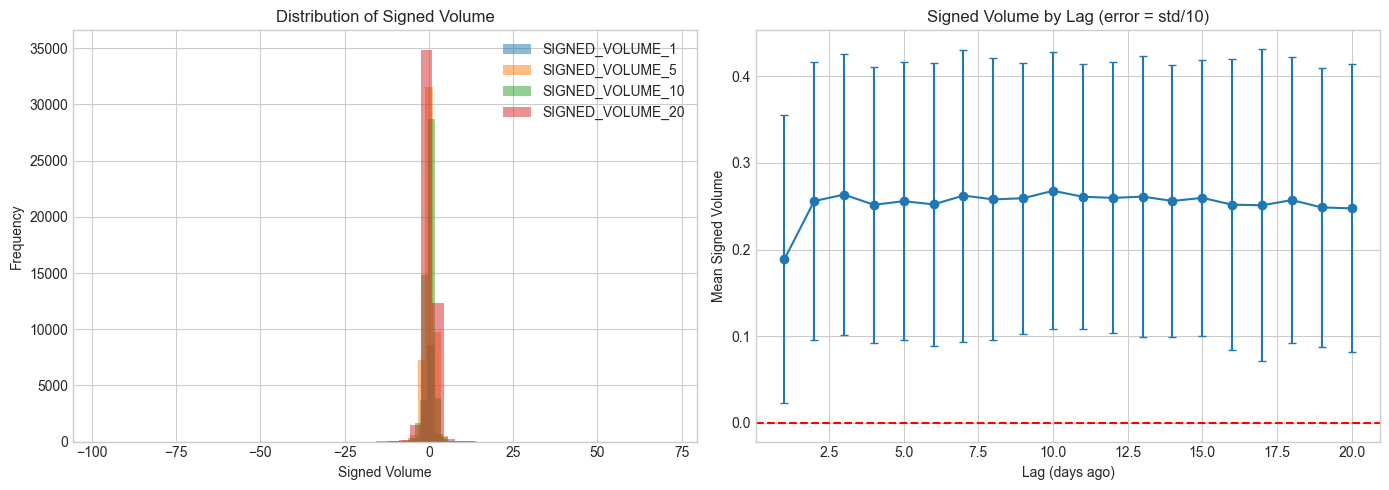

In [22]:
vol_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume distribution for recent days
for col in ['SIGNED_VOLUME_1', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_20']:
    axes[0].hist(df[col].dropna(), bins=50, alpha=0.5, label=col)
axes[0].set_xlabel('Signed Volume')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Signed Volume')
axes[0].legend()

# Volume stats over time
vol_means = [df[f'SIGNED_VOLUME_{i}'].mean() for i in range(1, 21)]
vol_stds = [df[f'SIGNED_VOLUME_{i}'].std() for i in range(1, 21)]

axes[1].errorbar(range(1, 21), vol_means, yerr=np.array(vol_stds)/10, 
                 marker='o', capsize=3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Lag (days ago)')
axes[1].set_ylabel('Mean Signed Volume')
axes[1].set_title('Signed Volume by Lag (error = std/10)')

plt.tight_layout()
plt.show()

## 9. Feature Engineering Ideas

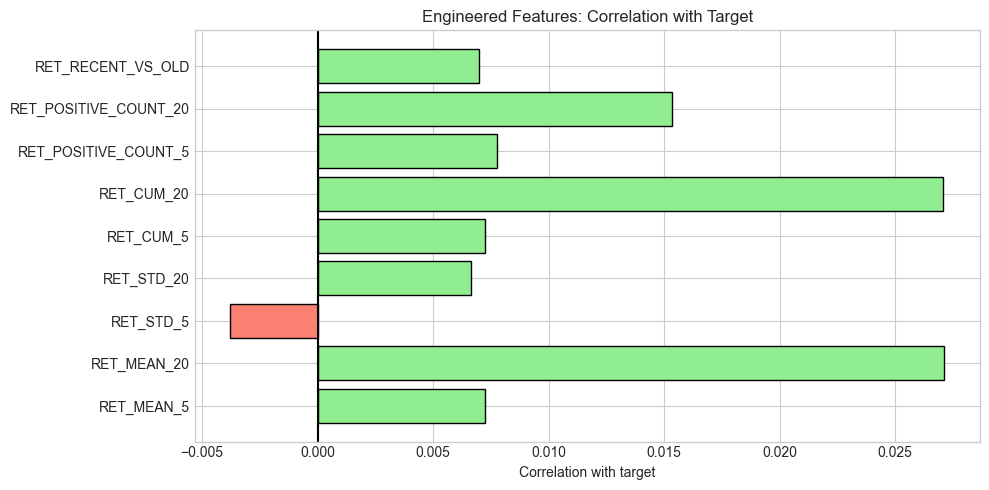


Engineered feature correlations:
RET_MEAN_20              0.0271
RET_CUM_20               0.0271
RET_POSITIVE_COUNT_20    0.0153
RET_POSITIVE_COUNT_5     0.0077
RET_CUM_5                0.0073
RET_MEAN_5               0.0073
RET_RECENT_VS_OLD        0.0070
RET_STD_20               0.0066
RET_STD_5               -0.0038
Name: target, dtype: float64


In [23]:
# Test some potential engineered features
df_fe = df.copy()

# Rolling statistics
ret_cols = [f'RET_{i}' for i in range(1, 21)]
df_fe['RET_MEAN_5'] = df_fe[[f'RET_{i}' for i in range(1, 6)]].mean(axis=1)
df_fe['RET_MEAN_20'] = df_fe[ret_cols].mean(axis=1)
df_fe['RET_STD_5'] = df_fe[[f'RET_{i}' for i in range(1, 6)]].std(axis=1)
df_fe['RET_STD_20'] = df_fe[ret_cols].std(axis=1)

# Cumulative return
df_fe['RET_CUM_5'] = df_fe[[f'RET_{i}' for i in range(1, 6)]].sum(axis=1)
df_fe['RET_CUM_20'] = df_fe[ret_cols].sum(axis=1)

# Momentum indicators
df_fe['RET_POSITIVE_COUNT_5'] = (df_fe[[f'RET_{i}' for i in range(1, 6)]] > 0).sum(axis=1)
df_fe['RET_POSITIVE_COUNT_20'] = (df_fe[ret_cols] > 0).sum(axis=1)

# Recent vs old
df_fe['RET_RECENT_VS_OLD'] = df_fe['RET_MEAN_5'] - df_fe[[f'RET_{i}' for i in range(16, 21)]].mean(axis=1)

# Check correlations with target
new_features = ['RET_MEAN_5', 'RET_MEAN_20', 'RET_STD_5', 'RET_STD_20', 
                'RET_CUM_5', 'RET_CUM_20', 'RET_POSITIVE_COUNT_5', 
                'RET_POSITIVE_COUNT_20', 'RET_RECENT_VS_OLD']

correlations = df_fe[new_features + ['target']].corr()['target'].drop('target')

plt.figure(figsize=(10, 5))
colors = ['lightgreen' if x > 0 else 'salmon' for x in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='black')
plt.axvline(0, color='black', linestyle='-')
plt.xlabel('Correlation with target')
plt.title('Engineered Features: Correlation with Target')
plt.tight_layout()
plt.show()

print("\nEngineered feature correlations:")
print(correlations.sort_values(ascending=False).round(4))

## 10. Key Takeaways

### Summary of findings:

1. **Target Balance**: Check if classes are balanced (~50/50 split)

2. **RET_1 is dominant**: Yesterday's return is by far the most predictive feature

3. **Momentum vs Mean Reversion**: Analyze the conditional probabilities to determine the regime

4. **Group differences**: Some groups may have systematically different win rates

5. **Feature engineering**: Rolling means, cumulative returns, and momentum indicators may help

6. **Volume features**: Generally weaker predictors than return features

### Next steps:
- Build baseline models (Logistic Regression, Random Forest, XGBoost)
- Feature selection based on importance
- Cross-validation strategy (careful with time-series aspects)
- Ensemble methods